# Predicting H1N1 Flu Vaccination Status
# OVERVIEW

H1N1 has a significant history marked by two major pandemics: the 1918 influenza pandemic and the 2009 H1N1 pandemic, both of which had profound impacts on global public health. The 2019 H1N1 pandemic, also referred to as "swine flu," caused high infections during the summer in the Northern Hemisphere and increased activity during the cooler seasons. Its unique characteristic is the high rates of infection and death among a relatively young population, unlike the seasonal flu, which affects the elderly more.

The H1N1 and seasonal flu vaccination dataset collects behavioral, health, and demographic information of individuals to understand vaccination patterns and predict who is likely to get vaccinated. The insights can guide public health campaigns, policy makers, planning, and development of strategic response measures, and resource mobilisation.

---
# Business Objective
The analysis of the H1N1 and Seasonal flu vaccine dataset will help in :
- Identifying the demographic groups  to be targeted for H1N1 vaccines 
- Indentifying Behavioral and belief patterns of the target groups on H1N1 vaccines
- Identifying the medical effectiveness and efficacy of H1N1 vaccines
- Identifying the influence of the professional medical recommendations and opinions on H1N1 vaccines
- Identifying strategies for addressing future H1N1 and seasonal flu outbreaks

---
## Key Questions

- How is my model predicting who is vaccinated or not accurately?
- What are the key factors that influence people to get H1N1 vaccine or not?

## Business Stakeholders
- Government authorities(National and county)
- Medical research and development institutions
- Healthcare providers and the professionals
- Disaster management response teams
- Donors and financiers

---

# Data Understanding
This data comes from United States National Center for Health Statistics: **The National Flu Survey from 2009**, which inquires about whether or not people received the seasonal flu and/or the H1N1 flu vaccination, as well as their demographic, behavioral, and health factors. There are 26,707 respondents to this survey. In this project i chose H1N1 vaccination rate as my target variable. I used all features in the survey, and filled missing values using the `Scikit sklearn SimpleImputer`.



In [58]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc,roc_auc_score

In [59]:
#Loading and reading features
df_sub = pd.read_csv("submission_format.csv")
df_sub

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,26707,0.5,0.7
1,26708,0.5,0.7
2,26709,0.5,0.7
3,26710,0.5,0.7
4,26711,0.5,0.7
...,...,...,...
26703,53410,0.5,0.7
26704,53411,0.5,0.7
26705,53412,0.5,0.7
26706,53413,0.5,0.7


In [60]:
df_test_features = pd.read_csv("test_set_features.csv")
df_test_features

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
1,26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
2,26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
3,26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
4,26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26703,53410,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,dqpwygqj,"MSA, Principle City",1.0,1.0,NaN,NaN
26704,53411,3.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Below Poverty,Married,Rent,Employed,qufhixun,Non-MSA,1.0,3.0,fcxhlnwr,vlluhbov
26705,53412,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,qufhixun,"MSA, Not Principle City",1.0,0.0,NaN,NaN
26706,53413,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,bhuqouqj,"MSA, Not Principle City",1.0,0.0,NaN,NaN


In [61]:
df_train_features = pd.read_csv("training_set_features.csv")
df_train_features

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg


In [62]:
df_train_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

In [63]:
df_training_labels = pd.read_csv("training_set_labels.csv")
df_training_labels

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0
...,...,...,...
26702,26702,0,0
26703,26703,0,0
26704,26704,0,1
26705,26705,0,0


In [64]:
#merging training dataset
Df_train = df_train_features.merge(df_training_labels,on ="respondent_id")
Df_train

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


In [65]:
#Checking the data information on missing values and datatypes
Df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

In [66]:
#Checking on the null values
Df_train.isnull().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

In [67]:
#Getting the correlation on the numerical features
Df_train.select_dtypes(include=['number']).corr()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
respondent_id,1.000000,0.017839,0.003425,-0.008475,0.009638,-0.006644,0.011105,0.004539,0.009011,0.007575,...,0.005912,0.000958,-0.002270,0.005935,-0.005291,0.009563,0.000187,-0.003726,-0.003280,-0.004652
h1n1_concern,0.017839,1.000000,0.062522,0.090301,0.233713,0.156032,0.293565,0.255031,0.246424,0.248016,...,0.239604,0.377033,0.360070,0.235136,0.333990,0.225731,-0.015658,0.050525,0.121929,0.154828
h1n1_knowledge,0.003425,0.062522,1.000000,-0.010836,0.088839,0.030050,0.089785,-0.048898,-0.068219,0.086162,...,0.121009,0.073086,-0.019501,0.086103,0.076825,-0.062483,0.024874,0.050583,0.117951,0.120152
behavioral_antiviral_meds,-0.008475,0.090301,-0.010836,1.000000,0.049247,0.146261,0.064119,0.106287,0.127679,0.070868,...,0.030211,0.105163,0.079091,0.015003,0.085315,0.084305,0.044900,0.084822,0.040608,0.006277
behavioral_avoidance,0.009638,0.233713,0.088839,0.049247,1.000000,0.064946,0.338130,0.227675,0.220348,0.335335,...,0.112300,0.117851,0.131405,0.119554,0.129504,0.082942,0.019122,0.040328,0.047690,0.076395
behavioral_face_mask,-0.006644,0.156032,0.030050,0.146261,0.064946,1.000000,0.083363,0.180907,0.163382,0.104335,...,0.037651,0.131165,0.107129,0.041556,0.110161,0.090009,0.013991,0.005826,0.070498,0.050083
behavioral_wash_hands,0.011105,0.293565,0.089785,0.064119,0.338130,0.083363,1.000000,0.195364,0.192619,0.365064,...,0.136987,0.168711,0.150024,0.138517,0.172464,0.088029,0.009669,0.047764,0.074712,0.112414
behavioral_large_gatherings,0.004539,0.255031,-0.048898,0.106287,0.227675,0.180907,0.195364,1.000000,0.584085,0.253683,...,0.052299,0.126463,0.185924,0.078491,0.132865,0.135446,-0.031938,-0.009449,0.017822,0.064025
behavioral_outside_home,0.009011,0.246424,-0.068219,0.127679,0.220348,0.163382,0.192619,0.584085,1.000000,0.267719,...,0.050748,0.125549,0.174834,0.067469,0.120237,0.138133,-0.027527,-0.009558,0.021768,0.053509
behavioral_touch_face,0.007575,0.248016,0.086162,0.070868,0.335335,0.104335,0.365064,0.253683,0.267719,1.000000,...,0.104126,0.146080,0.131772,0.105798,0.143735,0.090097,-0.000553,0.023606,0.071648,0.120228


In [68]:
#Defining the Target and the predictors
y = Df_train["h1n1_vaccine"]
x=Df_train.drop(["h1n1_vaccine","seasonal_vaccine","respondent_id"], axis = 1)



In [69]:
#Exploring percentages of the unvaccinated and vaccinated
y.value_counts(normalize = True) # 0-Unvaccinated, 1- Vaccinated

h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

# Data preparation
First, i dropped the "respondent_id" and "seasonal_vaccine" columns because they were not relevant for my analysis. Some columns were also due to categorical columns that are transformed with OneHotEncoder. I filled null values with Simple Imputer. I also decided to split training and testing data twice so that we could have a holdout set to test our final model's generalizability at the end.

I also noted that the ** majority class** (class 0) dominate with **about 78.75%** while the **minority class** (class 1)  is **21.24%**. This must be dealt with through regularization.

In [70]:
#Splitting data into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size =0.2)
x_train_filled =x_train.copy()

In [71]:
categorical_cols =x_train_filled.select_dtypes(include = "object")

x_train_cat = categorical_cols
x_train_cat

,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
24706,45 - 54 Years,Some College,White,Female,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",NaN,NaN
5393,45 - 54 Years,College Graduate,White,Male,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",wxleyezf,emcorrxb
20898,35 - 44 Years,NaN,White,Male,NaN,Married,NaN,Employed,qufhixun,"MSA, Not Principle City",xicduogh,xtkaffoo
3429,45 - 54 Years,College Graduate,Other or Multiple,Female,NaN,Not Married,Own,Employed,bhuqouqj,Non-MSA,cfqqtusy,ukymxvdu
8731,65+ Years,College Graduate,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
21575,55 - 64 Years,Some College,White,Male,"> $75,000",Not Married,Own,Not in Labor Force,qufhixun,"MSA, Principle City",NaN,NaN
5390,55 - 64 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Unemployed,mlyzmhmf,"MSA, Principle City",NaN,NaN
860,55 - 64 Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,Non-MSA,atmlpfrs,xqwwgdyp
15795,35 - 44 Years,College Graduate,Black,Female,"> $75,000",Married,Own,Employed,kbazzjca,"MSA, Principle City",fcxhlnwr,cmhcxjea


In [72]:
x_train_cat.isnull().sum()

age_group                    0
education                 1125
race                         0
sex                          0
income_poverty            3514
marital_status            1120
rent_or_own               1628
employment_status         1162
hhs_geo_region               0
census_msa                   0
employment_industry      10627
employment_occupation    10736
dtype: int64

In [86]:
#Filling categorical missing values with the mode by imputing
imputer= SimpleImputer(strategy = "most_frequent")
imputer.fit(x_train_cat)
imputed_cat = pd.DataFrame(imputer.fit_transform(x_train_cat),index=x_train_cat.index,columns=x_train_cat.columns)
imputed_cat.head()

,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
24706,45 - 54 Years,Some College,White,Female,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",fcxhlnwr,xtkaffoo
5393,45 - 54 Years,College Graduate,White,Male,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",wxleyezf,emcorrxb
20898,35 - 44 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",xicduogh,xtkaffoo
3429,45 - 54 Years,College Graduate,Other or Multiple,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,bhuqouqj,Non-MSA,cfqqtusy,ukymxvdu
8731,65+ Years,College Graduate,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",fcxhlnwr,xtkaffoo


In [74]:
x_train_filled_cat=imputed_cat
x_train_filled_cat.head()

,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
24706,45 - 54 Years,Some College,White,Female,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",fcxhlnwr,xtkaffoo
5393,45 - 54 Years,College Graduate,White,Male,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",wxleyezf,emcorrxb
20898,35 - 44 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",xicduogh,xtkaffoo
3429,45 - 54 Years,College Graduate,Other or Multiple,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,bhuqouqj,Non-MSA,cfqqtusy,ukymxvdu
8731,65+ Years,College Graduate,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",fcxhlnwr,xtkaffoo


In [75]:
#onehot encoding categorical columns
ohe = OneHotEncoder(sparse_output = False)
ohe.fit(x_train_filled_cat)
x_train_ohe = pd.DataFrame(ohe.transform(x_train_filled_cat),index=x_train_filled_cat.index,columns = ohe.get_feature_names_out(x_train_filled_cat.columns))

In [76]:
x_train_ohe

,age_group_18 - 34 Years,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_12 Years,education_< 12 Years,education_College Graduate,education_Some College,race_Black,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
24706,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5393,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3429,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8731,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5390,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15795,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
x_train_filled =x_train.copy()
numerical_cols =x_train_filled.select_dtypes(exclude = "object")

x_train_numerical = numerical_cols
x_train_numerical

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,5.0,4.0,2.0,4.0,4.0,2.0,1.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,NaN,5.0,4.0,4.0,5.0,4.0,4.0,0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,2.0,1.0,1.0,4.0,1.0,1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,4.0,2.0,1.0,4.0,2.0,2.0,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,3.0,2.0,5.0,5.0,2.0,5.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,4.0,2.0,2.0,4.0,2.0,1.0,0.0,0.0
5390,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,NaN,...,0.0,NaN,4.0,2.0,1.0,4.0,2.0,4.0,0.0,0.0
860,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,NaN,4.0,2.0,2.0,4.0,2.0,2.0,1.0,0.0
15795,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,4.0,1.0,1.0,4.0,1.0,0.0


In [78]:
#Filling missing values in the numerical columns using median by imputing
imputer= SimpleImputer(strategy = "median")
imputer.fit(x_train_numerical)
imputed_num = pd.DataFrame(imputer.fit_transform(x_train_numerical),index=x_train_numerical.index,columns=x_train_numerical.columns)


In [79]:
x_train_numerical=imputed_num
x_train_numerical

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,5.0,4.0,2.0,4.0,4.0,2.0,1.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,5.0,4.0,4.0,5.0,4.0,4.0,0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,2.0,1.0,1.0,4.0,1.0,1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,4.0,2.0,1.0,4.0,2.0,2.0,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,3.0,2.0,5.0,5.0,2.0,5.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,4.0,2.0,2.0,4.0,2.0,1.0,0.0,0.0
5390,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,4.0,2.0,1.0,4.0,2.0,4.0,0.0,0.0
860,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,4.0,2.0,2.0,4.0,2.0,2.0,1.0,0.0
15795,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,4.0,1.0,1.0,4.0,1.0,0.0


In [80]:
#Standardization of numerical columns
#mean=0,standard deviation =1
scale= StandardScaler()

x_train_scaled = pd.DataFrame(scale.fit_transform(x_train_numerical),index=x_train_numerical.index,columns=x_train_numerical.columns)
x_train_scaled

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
24706,0.419235,-0.427888,-0.227459,0.613397,-0.274987,0.462366,-0.744569,1.404097,0.690292,-0.505698,...,-0.352305,-3.795227,1.147026,1.297245,-0.262888,-0.027050,0.938861,-0.089913,0.146534,-0.572913
5393,0.419235,-0.427888,4.396392,0.613397,3.636532,0.462366,1.343058,1.404097,0.690292,-0.505698,...,-0.352305,0.263489,1.147026,1.297245,1.214971,0.905071,0.938861,1.423271,-1.185112,-0.572913
20898,-1.783386,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,1.404097,-1.448662,-0.505698,...,-0.352305,0.263489,-2.846653,-0.266358,-1.001818,-2.823411,0.938861,-0.846505,0.146534,0.506382
3429,-0.682076,-0.427888,-0.227459,-1.630265,-0.274987,-2.162788,-0.744569,-0.712202,-1.448662,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-1.001818,-0.027050,-0.514673,-0.089913,-1.185112,-0.572913
8731,-0.682076,-2.049354,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,-0.352305,0.263489,-0.849813,-0.266358,1.953901,0.905071,-0.514673,2.179863,0.146534,0.506382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,0.419235,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,0.690292,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-0.262888,-0.027050,-0.514673,-0.846505,-1.185112,-0.572913
5390,-0.682076,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,0.690292,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-1.001818,-0.027050,-0.514673,1.423271,-1.185112,-0.572913
860,0.419235,-0.427888,-0.227459,0.613397,-0.274987,-2.162788,-0.744569,-0.712202,0.690292,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-0.262888,-0.027050,-0.514673,-0.089913,0.146534,-0.572913
15795,0.419235,-0.427888,-0.227459,0.613397,-0.274987,0.462366,-0.744569,-0.712202,0.690292,1.977464,...,2.838451,0.263489,-2.846653,-1.048159,1.214971,-2.823411,-1.241440,1.423271,0.146534,-0.572913


In [81]:
# Combining processed categorical and numerical columns together into one dataframe
x_train_processed = pd.concat([x_train_scaled,x_train_ohe],axis=1)
x_train_processed

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
24706,0.419235,-0.427888,-0.227459,0.613397,-0.274987,0.462366,-0.744569,1.404097,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5393,0.419235,-0.427888,4.396392,0.613397,3.636532,0.462366,1.343058,1.404097,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20898,-1.783386,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,1.404097,-1.448662,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3429,-0.682076,-0.427888,-0.227459,-1.630265,-0.274987,-2.162788,-0.744569,-0.712202,-1.448662,-0.505698,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8731,-0.682076,-2.049354,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,0.419235,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5390,-0.682076,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,0.419235,-0.427888,-0.227459,0.613397,-0.274987,-2.162788,-0.744569,-0.712202,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15795,0.419235,-0.427888,-0.227459,0.613397,-0.274987,0.462366,-0.744569,-0.712202,0.690292,1.977464,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
#Test data


In [82]:
x_test_filled =x_test.copy()
x_test_filled


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,atmpeygn,"MSA, Principle City",NaN,NaN,NaN,NaN
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,fpwskwrf,"MSA, Principle City",1.0,1.0,NaN,NaN
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,NaN,Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",0.0,1.0,mfikgejo,mxkfnird
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"> $75,000",Married,Own,Employed,bhuqouqj,Non-MSA,1.0,2.0,cfqqtusy,xtkaffoo
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,"> $75,000",Married,Own,Employed,lrircsnp,"MSA, Principle City",1.0,0.0,wxleyezf,xtkaffoo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,1.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,"> $75,000",Married,Own,Employed,oxchjgsf,"MSA, Not Principle City",1.0,2.0,ldnlellj,hfxkjkmi
20086,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,oxchjgsf,"MSA, Not Principle City",0.0,0.0,arjwrbjb,rcertsgn
5045,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,Non-MSA,1.0,3.0,atmlpfrs,xqwwgdyp
6340,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"> $75,000",Married,Own,Employed,atmpeygn,"MSA, Principle City",1.0,3.0,vjjrobsf,rcertsgn


In [83]:
categorical_cols =x_test_filled.select_dtypes(include = "object")
x_test_cat = categorical_cols
x_test_cat.head()



,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
15772,18 - 34 Years,NaN,White,Female,NaN,NaN,NaN,NaN,atmpeygn,"MSA, Principle City",NaN,NaN
9407,35 - 44 Years,NaN,White,Male,NaN,NaN,NaN,NaN,fpwskwrf,"MSA, Principle City",NaN,NaN
16515,45 - 54 Years,College Graduate,White,Female,NaN,Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",mfikgejo,mxkfnird
23353,35 - 44 Years,College Graduate,White,Female,"> $75,000",Married,Own,Employed,bhuqouqj,Non-MSA,cfqqtusy,xtkaffoo
10008,55 - 64 Years,College Graduate,White,Male,"> $75,000",Married,Own,Employed,lrircsnp,"MSA, Principle City",wxleyezf,xtkaffoo


In [87]:

impute_test_cat = pd.DataFrame(imputer.transform(x_test_cat), index=x_test_cat.index, columns = x_train_cat.columns)
impute_test_cat

,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
15772,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,atmpeygn,"MSA, Principle City",fcxhlnwr,xtkaffoo
9407,35 - 44 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,fpwskwrf,"MSA, Principle City",fcxhlnwr,xtkaffoo
16515,45 - 54 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",mfikgejo,mxkfnird
23353,35 - 44 Years,College Graduate,White,Female,"> $75,000",Married,Own,Employed,bhuqouqj,Non-MSA,cfqqtusy,xtkaffoo
10008,55 - 64 Years,College Graduate,White,Male,"> $75,000",Married,Own,Employed,lrircsnp,"MSA, Principle City",wxleyezf,xtkaffoo
...,...,...,...,...,...,...,...,...,...,...,...,...
25132,35 - 44 Years,College Graduate,White,Female,"> $75,000",Married,Own,Employed,oxchjgsf,"MSA, Not Principle City",ldnlellj,hfxkjkmi
20086,45 - 54 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,oxchjgsf,"MSA, Not Principle City",arjwrbjb,rcertsgn
5045,45 - 54 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,Non-MSA,atmlpfrs,xqwwgdyp
6340,18 - 34 Years,Some College,White,Male,"> $75,000",Married,Own,Employed,atmpeygn,"MSA, Principle City",vjjrobsf,rcertsgn


In [88]:
x_test_cat =impute_test_cat
#oneHotEncode test data
x_test_ohe = pd.DataFrame(ohe.transform(x_test_cat),index=x_test_cat.index, columns=ohe.get_feature_names_out(x_train_cat.columns))
x_test_ohe

,age_group_18 - 34 Years,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_12 Years,education_< 12 Years,education_College Graduate,education_Some College,race_Black,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
15772,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23353,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10008,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20086,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5045,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6340,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
num_test_col = x_test_filled.select_dtypes(exclude ="object")
x_test_numerical = num_test_col
x_test_numerical

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,4.0,2.0,2.0,4.0,4.0,1.0,0.0,1.0
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,5.0,2.0,2.0,4.0,2.0,1.0,1.0,2.0
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,NaN,4.0,2.0,2.0,4.0,1.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,1.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,3.0,4.0,1.0,5.0,4.0,1.0,1.0,2.0
20086,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,4.0,2.0,1.0,4.0,2.0,1.0,0.0,0.0
5045,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,4.0,4.0,2.0,4.0,4.0,1.0,1.0,3.0
6340,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,NaN,4.0,2.0,2.0,2.0,4.0,1.0,1.0,3.0


In [90]:
#imputing test-numerical
imputer= SimpleImputer(strategy = "median")
imputer.fit(x_train_numerical)
imputed_test_num = pd.DataFrame(imputer.fit_transform(x_test_numerical),index=x_test_numerical.index,columns=x_test_numerical.columns)
x_test_numerical=imputed_test_num



In [91]:
#Standardization

x_test_scaled = pd.DataFrame(scale.transform(x_test_numerical),index=x_test_numerical.index,columns=x_test_numerical.columns)
x_test_scaled

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
15772,0.419235,-0.427888,-0.227459,0.613397,3.636532,0.462366,1.343058,1.404097,0.690292,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-0.262888,-0.027050,-0.514673,-0.089913,0.146534,-0.572913
9407,1.520546,-2.049354,-0.227459,0.613397,3.636532,0.462366,1.343058,1.404097,-1.448662,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-0.262888,-0.027050,-0.514673,-0.089913,0.146534,0.506382
16515,-0.682076,-0.427888,-0.227459,0.613397,-0.274987,0.462366,1.343058,1.404097,0.690292,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-0.262888,-0.027050,0.938861,-0.846505,-1.185112,0.506382
23353,0.419235,1.193578,-0.227459,0.613397,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,-0.352305,0.263489,1.147026,-0.266358,-0.262888,-0.027050,-0.514673,-0.846505,0.146534,1.585678
10008,-0.682076,1.193578,-0.227459,0.613397,-0.274987,0.462366,1.343058,-0.712202,0.690292,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-0.262888,-0.027050,-1.241440,-0.089913,0.146534,-0.572913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,-0.682076,1.193578,-0.227459,0.613397,3.636532,0.462366,1.343058,-0.712202,0.690292,-0.505698,...,-0.352305,0.263489,-0.849813,1.297245,-1.001818,0.905071,0.938861,-0.846505,0.146534,1.585678
20086,-0.682076,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,-0.352305,0.263489,0.148606,-0.266358,-1.001818,-0.027050,-0.514673,-0.846505,-1.185112,-0.572913
5045,0.419235,1.193578,-0.227459,0.613397,-0.274987,0.462366,-0.744569,-0.712202,0.690292,1.977464,...,-0.352305,0.263489,0.148606,1.297245,-0.262888,-0.027050,0.938861,-0.846505,0.146534,2.664974
6340,1.520546,-2.049354,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,2.838451,0.263489,0.148606,-0.266358,-0.262888,-1.891291,0.938861,-0.846505,0.146534,2.664974


In [92]:
x_test_processed = pd.concat([x_test_scaled, x_test_ohe], axis =1)
x_test_processed

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv
15772,0.419235,-0.427888,-0.227459,0.613397,3.636532,0.462366,1.343058,1.404097,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,1.520546,-2.049354,-0.227459,0.613397,3.636532,0.462366,1.343058,1.404097,-1.448662,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,-0.682076,-0.427888,-0.227459,0.613397,-0.274987,0.462366,1.343058,1.404097,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23353,0.419235,1.193578,-0.227459,0.613397,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10008,-0.682076,1.193578,-0.227459,0.613397,-0.274987,0.462366,1.343058,-0.712202,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,-0.682076,1.193578,-0.227459,0.613397,3.636532,0.462366,1.343058,-0.712202,0.690292,-0.505698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20086,-0.682076,-0.427888,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5045,0.419235,1.193578,-0.227459,0.613397,-0.274987,0.462366,-0.744569,-0.712202,0.690292,1.977464,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6340,1.520546,-2.049354,-0.227459,-1.630265,-0.274987,0.462366,-0.744569,-0.712202,-1.448662,-0.505698,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Modelling
My H1N1 vaccination prediction will use Logistic Regression modelling approach. To evaluate predictability of the target accurately, i model a baseline model without any hyperameter and a second model which is an improved or regularized logistic regression model.

Key performance metrics i will use to evaluate are:-
- **Accuracy_score**
- **Precision**
- **Recall**
- **F1 score**
- **ROC_curve and AUC**

## Baseline Model

In [93]:
logreg =LogisticRegression()
baseline_model=logreg.fit(x_train_processed,y_train)
baseline_model

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [94]:
y_train_preds = logreg.predict(x_train_processed)

In [95]:
y_train_preds = logreg.predict(x_train_processed)

Baseline_model_train_accuracy = accuracy_score(y_train, y_train_preds)
Baseline_model_train_accuracy

0.8373976129183244

In [96]:
y_test_preds = logreg.predict(x_test_processed)

In [97]:
y_test_preds = logreg.predict(x_test_processed)

Baseline_model_test_accuracy = accuracy_score(y_test, y_test_preds)
Baseline_model_test_accuracy

0.8395731935604642

In [ ]:
print(f"The training baseline model accuracy: {Base_train_accuracy:.4f}")
print(f"The testing baseline model accuracy: {Baseline_model_test_accuracy:.4f}")

## Interpretation
The model demonstrates strong generalization performance, with **training accuracy (83.74%** and **testing accuracy (83.96%)** being nearly identical. This indicates that the model is neither **overfitting** nor **underfitting**, and is able to effectively capture underlying patterns in the data. The minimal difference between training and testing performance suggests good robustness and reliability on unseen 

However, accuracy alone may not be sufficient, especially if the dataset is imbalanced as in our case (78% class 0, 21% class 1). Additional metrics such as precision, recall, and F1-score should be considered for a more comprehensive evaluation.

In [98]:
baseline_model_cm = confusion_matrix(y_test, y_test_preds, labels=[0,1])
baseline_model_cm

array([[4004,  208],
       [ 649,  481]], dtype=int64)

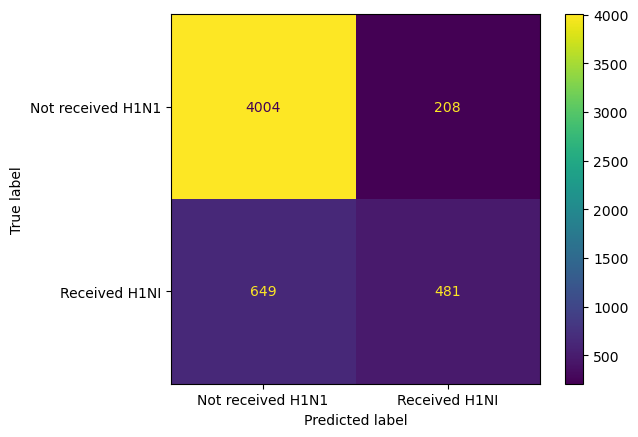

In [100]:
Baseline_model_disp = ConfusionMatrixDisplay(confusion_matrix=baseline_model_cm,  display_labels=['Not received H1N1', 'Received H1NI'])
Baseline_model_disp.plot()

In [101]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4212
           1       0.70      0.43      0.53      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.69      0.72      5342
weighted avg       0.83      0.84      0.82      5342



In [102]:
y_score = logreg.fit(x_train_processed, y_train).decision_function(x_test_processed)
print(y_score)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
print(thresholds)
print('AUC: {}'.format(auc(fpr, tpr)))

[-2.2393021  -2.46613455 -3.06486984 ...  0.81061995 -2.6725532
 -3.22758838]
[ 5.19692579  4.19692579  2.81492669 ... -4.91185303 -4.93395113
 -6.120339  ]
AUC: 0.8313680256158132


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


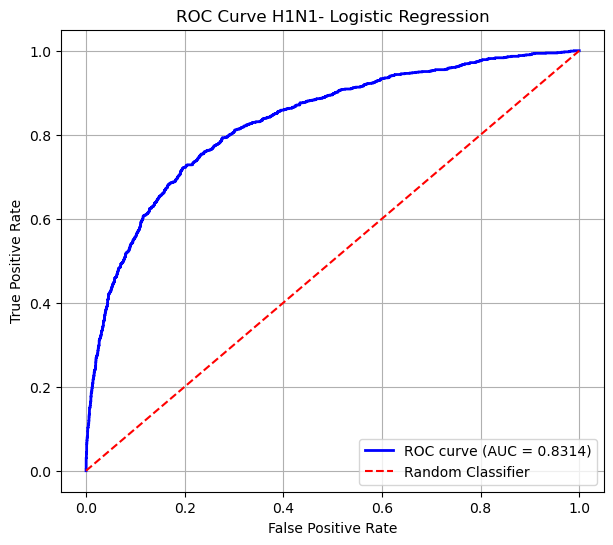

In [103]:
# Predicted probabilities for the positive class 
y_prob = logreg.predict_proba(x_test_processed)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve H1N1- Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Baseline model Evaluation
The model exposes important imbalance issues where:
- The model excellently predicted the majority class(class 0) as exhibited by the performance of `precision`, `recall`, `f1-score`.
- The recall score of 43% means that the model only accurately predicted 43% out of all class 1 and misses a whooping 57%.

The model achieves an overall accuracy of 84%, indicating good general performance. However, there is a significant imbalance in class-wise performance. While the model performs well on the majority class (class 0) with a high recall of 95%, it struggles to correctly identify the minority class (class 1), achieving a recall of only 43%. This indicates that a large proportion of positive cases are misclassified as negative. Therefore, despite high accuracy, the model is not well-suited for applications where correctly identifying class 1 instances is critical.

## Regularized model

In [104]:
logreg_im = LogisticRegression(solver ="sag",class_weight ="balanced",C=100, max_iter = 1000)

In [105]:
improved_model_train =logreg_im.fit(x_train_processed,y_train)
improved_model_train

LogisticRegression(C=100, class_weight='balanced', max_iter=1000, solver='sag')

In [106]:
#prediction-train
y_train_preds_im = improved_model_train.predict(x_train_processed)

In [107]:
improve_model_train_accuracy = accuracy_score(y_train,y_train_preds_im)
improve_model_train_accuracy

0.7817458460098292

In [108]:
improved_model_test =logreg_im.fit(x_test_processed,y_test)
improved_model_test

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=100, class_weight='balanced', max_iter=1000, solver='sag')

In [111]:
#prediction-test
y_test_preds_im = improved_model_test.predict(x_test_processed)


In [112]:
improve_model_test_accuracy = accuracy_score(y_test,y_test_preds_im)
improve_model_test_accuracy

0.7806065144140771

In [113]:
improve_model_cm = confusion_matrix(y_test, y_test_preds_im, labels=[0,1])
improve_model_cm

array([[3341,  871],
       [ 301,  829]], dtype=int64)

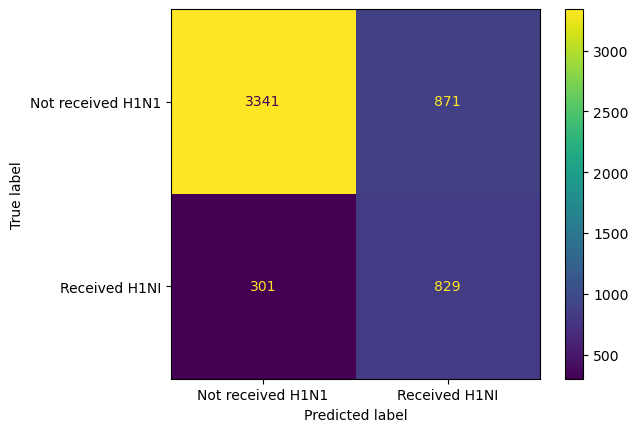

In [114]:
improve_model_disp = ConfusionMatrixDisplay(confusion_matrix=improve_model_cm,  display_labels=['Not received H1N1', 'Received H1NI'])
improve_model_disp.plot()

In [115]:
print(classification_report(y_test, y_test_preds_im))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85      4212
           1       0.49      0.73      0.59      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.72      5342
weighted avg       0.83      0.78      0.79      5342



In [134]:
report_dict=classification_report(y_test,y_test_preds_im, output_dict=True)
report_df =pd.DataFrame(report_dict).transpose()
report_df.to_csv("class_report.csv")
                                  

In [116]:
y_score = logreg_im.fit(x_train_processed, y_train).decision_function(x_test_processed)
print(y_score)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
print('AUC: {}'.format(auc(fpr, tpr)))

[-0.82150723 -0.91634438 -1.94135393 ...  2.19644223 -1.37172493
 -2.08518553]
AUC: 0.8316857020396844


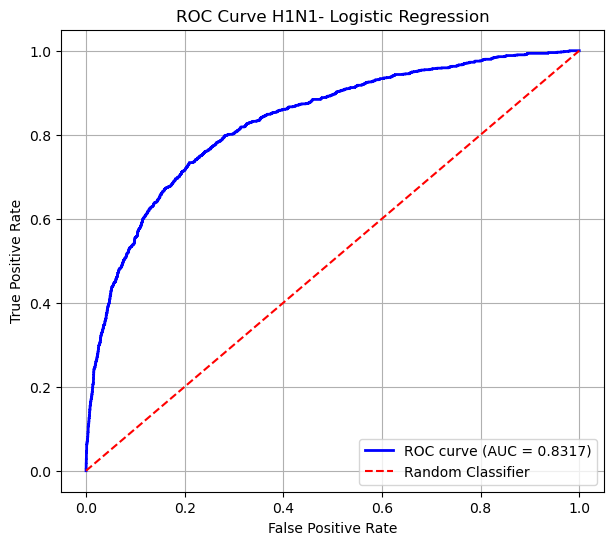

In [117]:
# Predicted probabilities for the positive class 
y_prob = logreg_im.predict_proba(x_test_processed)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve H1N1- Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Regularized model Evaluation
The baseline model accuracy score is 83.96%, while the regularized model accuracy score is 78.06%. The drop in accuracy is expected because the regularized model reduces overfitting and no longer over-predicts the majority class. It provided a better balance between precision and recall for the minority class, which is more critical for this problem.

The model performs well in identifying non-vaccinated individuals (F1-score of 0.85) and shows strong recall for vaccinated individuals (0.73), meaning it successfully captures most of them. However, the precision for the vaccinated class is relatively low (0.49), indicating a higher number of false positives. Overall, the model provides a better balance between classes compared to the baseline and is more suitable for scenarios where identifying vaccinated individuals is important.



## Exploratory Data Analysis(EDA)

### 1. H1N1 Vaccination distribution

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

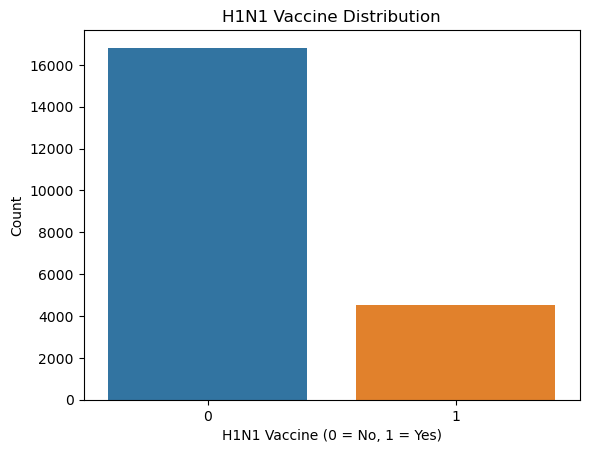

In [121]:
sns.countplot(x=y_train)
plt.title("H1N1 Vaccine Distribution")
plt.xlabel("H1N1 Vaccine (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The representations of the target variables shows a clear biases in favour of class 0. This firms the representations of class imbalances of 78% against 21%. 

### 2. H1N1 Vaccine Effectiveness Against Perception

In [ ]:
x[['opinion_h1n1_vacc_effective']].isnull().sum()

In [122]:
x=x.dropna(subset=['opinion_h1n1_vacc_effective'])
x[['opinion_h1n1_vacc_effective']].isnull().sum()

opinion_h1n1_vacc_effective    0
dtype: int64

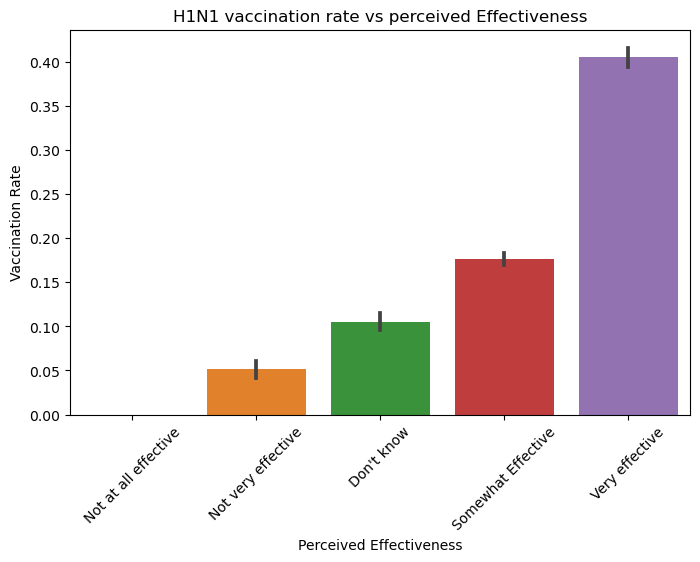

In [123]:
H1N1_Vacc_effective = {1: ' Not at all effective', 2: 'Not very effective', 3: "Don't know", 4: 'Somewhat Effective', 5:'Very effective'}
Vaccine_effectiveness =x['opinion_h1n1_vacc_effective'].map(H1N1_Vacc_effective)

order =["Not at all effective","Not very effective", "Don't know", "Somewhat Effective", "Very effective"]

plt.figure(figsize =(8,5))
sns.barplot(data=x_train_processed,x=Vaccine_effectiveness,y=Df_train["h1n1_vaccine"], order=order)
plt.title("H1N1 vaccination rate vs perceived Effectiveness")
plt.xlabel("Perceived Effectiveness")
plt.ylabel("Vaccination Rate")
plt.xticks(rotation=45)
plt.show()


People who believe the H1N1 vaccine is effective **(about 44%)** are much more likely to get vaccinated. The sharp increase from the `Somewhat Effective` to `Very effective` suggest that belief in the vaccine efficacy is a major behavioural driver. The about **12%** group of `Don't know` are unsure of the vaccine effectiveness. This alone suggest that more education is needed to increase vaccination rates.

In a nutshell, perception of vaccine effectiveness of the H1N1 vaccine strongly influences uptake. Individuals who believe the vaccine is very effective are significantly more likely to be vaccinated compared to those who perceive it as ineffective. This suggests that **public health messaging and campaigns focussed on vaccine effectiveness could substantially improve vaccination rates**.

In [ ]:
x.info()

### Doctor Recommendation on H1N1 uptake

In [ ]:
x['doctor_recc_h1n1'].value_counts()

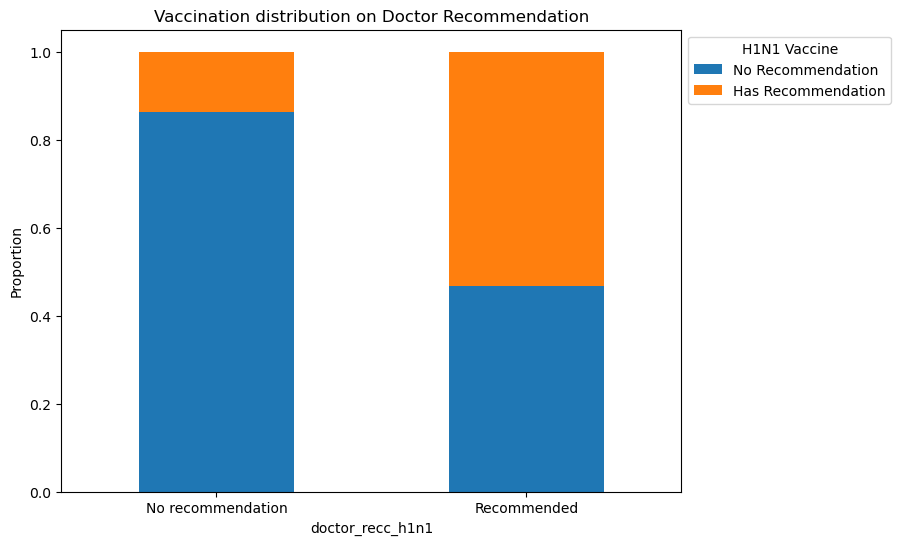

In [124]:
Doc_recc = pd.crosstab(x['doctor_recc_h1n1'],y, normalize = 'index')

Doc_recc.plot(kind="bar",stacked =True, figsize =(8,6))
plt.xticks([0,1],['No recommendation', 'Recommended'],rotation =0)
plt.title("Vaccination distribution on Doctor Recommendation")
plt.ylabel("Proportion")
plt.legend(title='H1N1 Vaccine', labels= ['No Recommendation', 'Has Recommendation'], loc ='upper left', bbox_to_anchor =(1,1))
plt.show()

- **No Doctor recommendation** -most people did **not get vaccinated(about 88%)**
- **Doctor recommendation** -most people **did get vaccination(about 55%)** and few people did **not get vaccinated(about 45%)**

The chart shows that individuals who received  a doctor's recommendation were significantly more likely to get H1N1 vaccine. This highlights the critical role healthcare providers play in influencing vaccination decisions. Public health campaigns targeting doctor advice could sbstantially increase vaccine uptake.

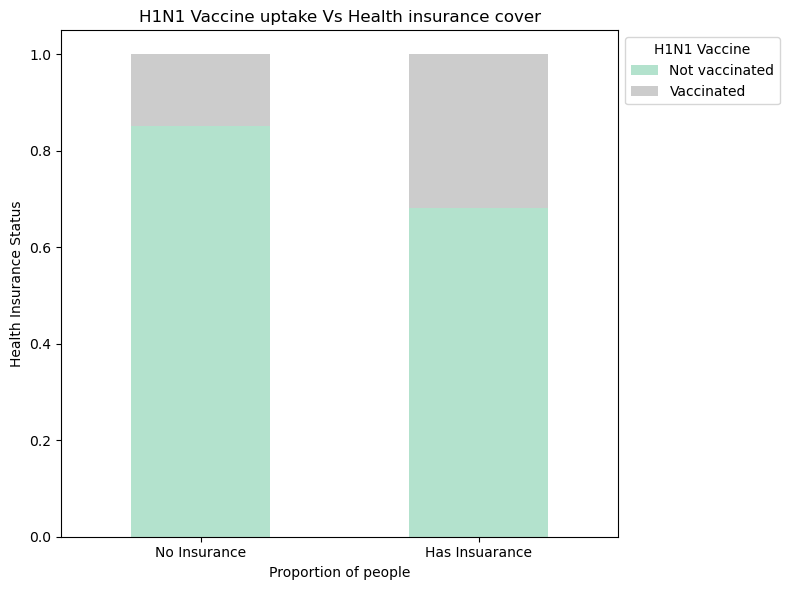

In [125]:
x=x.dropna(subset=["health_insurance"])
Health_insur =pd.crosstab(x["health_insurance"],y,normalize ='index')

Health_insur.plot(kind = "bar", stacked =True, figsize=(8,6),colormap = 'Pastel2')

plt.title("H1N1 Vaccine uptake Vs Health insurance cover")
plt.ylabel("Health Insurance Status")
plt.xlabel("Proportion of people")
plt.xticks([0,1],['No Insurance', 'Has Insuarance'],rotation =0)
plt.legend(title='H1N1 Vaccine', labels= ['Not vaccinated', 'Vaccinated'], loc ='upper left', bbox_to_anchor =(1,1))
plt.tight_layout()
plt.show()

- **No Insurance**- Only a small size of the people without insurance got vaccinated(About 14%) and a bigger proportion did get vaccinated.
- **Has Insurance** -A better proportion of people with insurance cover did receive vaccination.

Even among the people with insurance cover,those not vaccinated is still high. This suggests that while insurance is key facilitator to vaccines access, it is not the only factor.

The chart clearly depicts a strong positive correlation between health insurance coverage and the H1N1 vaccination rates. While the overall vaccinated population is minority in both groups,individuals with health cover were more likely to receive the vaccine than those without.This suggests that expanding insurance coverage or providing free, low_barrier vaccination clinics is essential for achieving higher public health immunity.

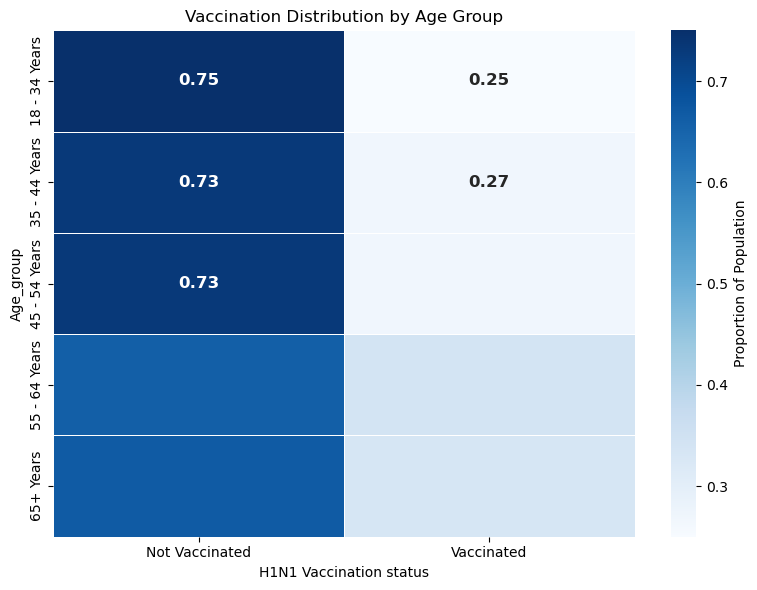

In [127]:
Age_H1N1_vacc =pd.crosstab(x['age_group'],y, normalize = 'index')
Age_H1N1_vacc.columns =['Not Vaccinated','Vaccinated']
plt.figure(figsize=(8,6))
sns.heatmap(Age_H1N1_vacc,annot =True, cmap= 'Blues',fmt='.2f', linewidths =0.5, cbar_kws={'label': 'Proportion of Population'},annot_kws ={"size":12,"weight":"bold"})
plt.title("Vaccination Distribution by Age Group")
plt.ylabel("Age_group")
plt.xlabel("H1N1 Vaccination status")
plt.tight_layout()
plt.show()

- **High Non_Vaccination in younger Groups**: There is a significant concentration of unvaccinated individuals in the the 18-54years. However, as the age increases the proportion of unvaccinated indivduals appears to decrease indicated by lighter blue shading in age groups of 55-65 yera and above.

The data suggests a clear age_based disparity in vaccination status. The primary target for public outreach ,based on this heatmap,would be the 18-34 age group which commands the **highest rate(75%** of the unvaccinated indivduals.

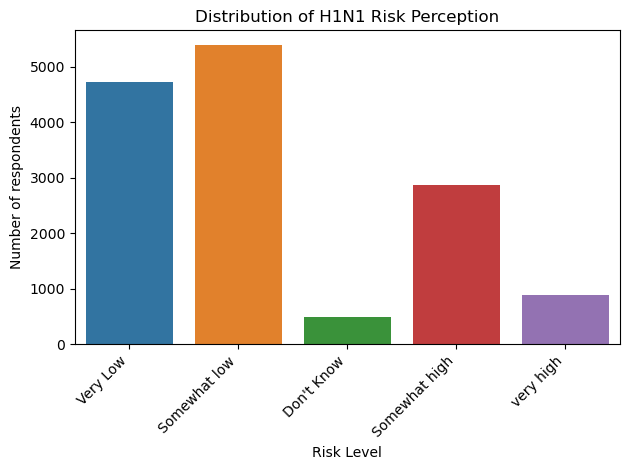

In [128]:
x=x.dropna(subset=['opinion_h1n1_risk'])
x[['opinion_h1n1_risk']].isnull().sum()
sns.countplot(data=x, x=x["opinion_h1n1_risk"])
labels =['Very Low', 'Somewhat low', "Don't Know", "Somewhat high", "very high"] 
position=range(len(labels))
plt.title("Distribution of H1N1 Risk Perception")
plt.xlabel("Risk Level")
plt.ylabel("Number of respondents")
plt.xticks(position,labels,rotation =45,ha = 'right')
plt.tight_layout()
plt.show()

Most people perceive H1N1 risk as low, with a large proportion selecting `Very Low` or `Somewhat low` commanding over 18000 individuals(more than 50% of the total respondents). The `Don't Know` group is the lowest overall suggesting people have a firm opinion on their risk level. Very few people are truly undecided or uninformed about where they stand.

# Findings

### Rationale
H1N1 vaccine and seasonal flu dataset is majorly categorical and the target is binary making it ideal for prediction. The flexibility of fine tuning the parameters to address the issues of class imbalances,overfitting,underfitting and availability of evaluation metrics makes machine learning approach more reliable than any other simple data analysis methods.

### Results
#### Baseline model 
The model is very good at predicting the unvaccinated(class 0) but struggles to identify the vaccinated people. This is attributed to the class imbalance.

**Precision** - 0.86(class 0 - unvaccinated),0.70(class 1-vaccinated). When the model predicts class 0, it is always 86% accurate but when it predicts class 1, the model is 70% accurate. The 30% False positive is dangerous since these are the people the model predicts to be vaccinated yet they are actually at risk of getting sick.

**Recall** - 0.95(class 0),0.43(class 1). The model identifies 95% of the unvaccinated population and only 43% of the vaccinated population. The model misses 57% of vaccinated people(False Negatives)

### Regularised model
The accuracy dropped from 84% to 78% from the baseline model. This is because the model is no longer biased towards the majority class, reflecting a more realistic performance.

The model demonstrates a significant increase in recall for vaccinated individuals(from 43% to 73%), indicating a better ability to identify individuals likely to receive the H1N1 vaccine. Although overall accuracy decreased due to the trade-off favouring recall over precision. This shift is appropriate, given the importance of minimising false negatives in public health contexts.

The improved model is better than the baseline model since, in public health, high recall(finding everyone who needs attention) is more preferred than high precision(being perfectly right about every guess).

The AUC of `0.8317` is considered "good" to "very good". This means my model has 83% chance to be able to distinguish between  arandomly chosen vaccinated person and a randomly chosen unvaccinated person.


                   

### Limitations
The analysis of the H1N1 vaccine predictions can be limited by:
 1. The data used is historical. Using nearly two decades old data may not clearly reflect on the current situation, where there are always shifts in technologies, evolving research and developments in the medical fields, other chronic diseases becoming more prevalent and compromising human immunity systems
  2. The modelling methods may not actually predict accurately. Predictive models can lead to misclassification. The training model can memorise the training data and fails when exposed to new unseen data, which in the long run fails to handle real world problem.
  3. Features- The features used in modelling are not the only determining features of the vaccine uptake. Other factors like availability and accessibility of the vaccine, government interventions and policy, quality of healthcare providers, vaccine information availabilty among other factors play a key role in shaping the uptake
  4. Biasness. The data used is a survey done through phone calls. This raises credibility issues from the source since the respondents may be having a prejudged opinion about the vaccine.

# Conclusions
The objective of this analysis was to predict H1N1 vaccine uptake based on demographic and behavioral factors. Simple exploratory data analysis revealed that factors like doctor recommendations, vaccine risk perception, vaccine effectiveness, efficacy, and health insurance cover play a key role in influencing vaccination decisions.

The baseline logistic regression model achieved an accuracy of 84%, but performed poorly in identifying vaccinated individuals, with low recall. After improving the model using class balancing techniques, recall for vaccinated individuals increased significantly from 43% to 73%, although overall accuracy decreased slightly to 78%.

This trade-off indicates that the regularised model is more effective in identifying individuals likely to receive the vaccine, which is critical in a public health context. Overall, the analysis demonstrates the importance of addressing class imbalance and focusing on recall when predicting health-related behaviors

# Recommendations
From the findings:-
  1. Since improved model demonstrated higher recall in identifying individuals likely to receive the H1N1 vaccine,future models should prioritize recall over accuracy to minimise missed cases. Further optimisation can be achieved by tuning the classification threshold to balance precision and recall more effectively.
  2. Strong influence from the health-related factors indicates that public health strategies should focus on increasing awareness and encouraging awareness and encouraging healthcare providers to actively recommend vaccinations
  3. Use other more advanced classification models or methods to do analysis
  4. The data should be current to reflect what is happening at the time rather than predicting using historical records.